**Sentiment Analysis is an NLP** **technique used to analyze text and** **determine the sentiment expressed in** **it, such as Positive, Negative,**
**or Neutral.**

In [1]:
# Import Required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Read the dataset
df=pd.read_excel("/content/dataset.xlsx")

In [3]:
# View dataset
df

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


# **Exploratory Data Analysis**

In [4]:
# Check no. of rows and columns present in dataset
df.shape

(1440, 3)

In [5]:
# Check column names
df.columns

Index(['title', 'rating', 'body'], dtype='object')

In [6]:
# Check top 5 entries of dataset
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [7]:
# Check quick info of df like data type, non-null counts, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [8]:
# Check for null values
df.isna().sum()

,0
title,0
rating,0
body,0


In [9]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [10]:
# check the unique ratings given by the user
df['rating'].unique()

array([1, 3, 4, 5, 2])

In [11]:
# Create the sentiment column with classes Negative, Neutral and Positive.
def get_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["sentiment"] = df["rating"].apply(get_sentiment)

print(df[["rating", "sentiment"]].head(10))

   rating sentiment
0       1  Negative
1       3   Neutral
2       4  Positive
3       1  Negative
4       1  Negative
5       1  Negative
6       1  Negative
7       1  Negative
8       1  Negative
9       1  Negative


In [12]:
# Check whether sentiment column is added in df or not
df

,title,rating,body,sentiment
0,Horrible product,1,Very disappointed with the overall performance...,Negative
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative
...,...,...,...,...
1435,Excellent mobile,5,Excellent mobile,Positive
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve...",Negative
1437,Good value for money,5,Battery life is good but camera clarity could ...,Positive
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied.....",Negative


In [13]:
# check unique values of sentiment column with its count
df["sentiment"].value_counts()

,count
sentiment,
Positive,729
Negative,512
Neutral,199


In [14]:
# Calculate percentage of each sentiment
sentiment_percentage = df["sentiment"].value_counts(normalize=True) * 100

print(sentiment_percentage)

sentiment
Positive    50.625000
Negative    35.555556
Neutral     13.819444
Name: proportion, dtype: float64


In [15]:
# Combine title and review (body) column & create new column named as text
df["text"] = df["title"].fillna("") + " " + df["body"].fillna("")

df[["title", "body", "text"]].head()

,title,body,text
0,Horrible product,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...
1,Camera quality is not like 48 megapixel,Camera quality is low,Camera quality is not like 48 megapixel Camera...
2,Overall,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt..."
3,A big no from me,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...
4,Put your money somewhere else,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...


# **Language Detection and Translation**

In [16]:
import re

# Function to check whether the text contains non-Latin characters
def contains_non_latin(text):
    text = str(text) # Convert the input to string


    # Search for (Hindi/Marathi) or Malayalam characters
    # Return True if any such character is found, otherwise False
    return bool(
        re.search(r'[\u0900-\u097F\u0D00-\u0D7F]', text)
    )

# Apply the function to the 'text' column
# Creates a new column indicating whether translation is required
df["needs_translation"] = df["text"].apply(contains_non_latin)

In [17]:
print(df["needs_translation"].value_counts())

needs_translation
False    1427
True       13
Name: count, dtype: int64


In [18]:
# Displays only the rows where translation is required
print(df[df["needs_translation"]][["text", "rating"]])

                                                   text  rating
7     कैसा दिखाते है उसका 10 % भी नही मोबाइल का कैमर...       1
248   Damage product reshived Damage product reshive...       1
407   STPL SUPPLIER SEND WRONG ITEM 8 ന്റെ പണിAmazon...       1
421   अमेज़न आपके द्वारा खरीदा samsung m12 6GB ram 12...       1
460   असंतोषजनक इस फोन में कई कमियां है जैसे इसकी नो...       1
524   पैसे की बर्बादी है ये मोबाइल घण्टा true 48 meg...       2
700   सैमसंग के मोबाइल के मेरे लिए बेस्ट रहते है। ये...       4
794   इस फोन में बहुत सारे प्रॉब्लम है इस फोन में बह...       1
803   Samsung worst phone ever ना तो dual app work क...       1
887   बकबास फ़ोन,  पैसे खड्डे में गए Worst phone.  एक...       1
1051  कैमरा इस mobile का कैमरा बहुत ही बकवास हैं कम्...       1
1301  Very bad 👎 कैमरा क्वालिटी बिल्कुल खराब है बैटर...       1
1369  बहुत ही अच्छा कैमरा और बैटरी बैकअप है इस फोन क...       5


In [19]:
# transformers     → Used for pre-trained NLP/translation models
# sentencepiece    → Required by some Transformer-based language models
# langdetect       → Used to detect the language of the text

!pip install -q transformers sentencepiece langdetect

In [20]:
# Import PyTorch for checking and using GPU/CPU
import torch

# Import tokenizer and sequence-to-sequence model classes
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Import tokenizer and sequence-to-sequence model classes
model_name = "facebook/nllb-200-distilled-600M"

tokenizer = AutoTokenizer.from_pretrained(model_name) # Load the tokenizer associated with the model
model = AutoModelForSeq2SeqLM.from_pretrained(model_name) # Load the pre-trained translation model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Use GPU (CUDA) if available; otherwise use CPU
model = model.to(device) # Move the model to the selected device

print("Device:", device) # Displays which device is being used

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Device: cpu


In [21]:
from langdetect import detect, DetectorFactory, LangDetectException

# Set a fixed seed to make language detection results reproducible
DetectorFactory.seed = 42

# Function to detect the language of the given text
def detect_language(text):
    text = str(text).strip() # Convert the input to string and remove extra spaces

    # Return "unknown" if the text is empty
    if not text:
        return "unknown"

    try:
        # Detect and return the language code
        return detect(text)

         # Return "unknown" if language detection fails
    except LangDetectException:
        return "unknown"

In [22]:
# Test the language detection function with English text
print(detect_language("This phone has a very good camera"))

# Test with Hindi text
print(detect_language("यह मोबाइल बहुत अच्छा है"))

# Test with Malayalam text
print(detect_language("ഈ ഫോൺ വളരെ നല്ലതാണ്"))

en
hi
ml


In [23]:
language_map = {

    # English
    "en": "eng_Latn",

    # Indian Languages
    "hi": "hin_Deva",
    "mr": "mar_Deva",
    "bn": "ben_Beng",
    "ta": "tam_Taml",
    "te": "tel_Telu",
    "ml": "mal_Mlym",
    "gu": "guj_Gujr",
    "kn": "kan_Knda",
    "pa": "pan_Guru",
    "ur": "urd_Arab",
    "ne": "npi_Deva",

    # European Languages
    "fr": "fra_Latn",
    "de": "deu_Latn",
    "es": "spa_Latn",
    "it": "ita_Latn",
    "pt": "por_Latn",

    # Other commonly used Languages
    "ru": "rus_Cyrl",
    "ar": "arb_Arab",
    "ja": "jpn_Jpan",
    "ko": "kor_Hang",

    # Chinese Languages
    "zh-cn": "zho_Hans",
    "zh-tw": "zho_Hant"
}

In [24]:
# Function to translate non-English text into English
def translate_to_english(text):

    text = str(text).strip() # Convert input to string and remove extra spaces

    # If the text is empty, return it as it is
    if not text:
        return text

    # Detect language of the text
    try:
        detected_lang = detect(text)
    except:
      # If language detection fails, keep the original text
        return text

    # If already English, don't translate
    if detected_lang == "en":
        return text

    # Check whether the detected language is supported by our mapping
    if detected_lang not in language_map:
        print("Language not supported:", detected_lang)
        return text

    # Get the NLLB language code corresponding to the detected language
    source_language = language_map[detected_lang]

    try:

        # Set the source language for the NLLB tokenizer
        tokenizer.src_lang = source_language

        # Convert the text into tokens that the model can process
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )

        # Move the input tensors to the selected device (CPU/GPU)
        inputs = {key: value.to(device) for key, value in inputs.items()}

        # Generate the English translation
        translated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids("eng_Latn"),
            max_length=512
        )

        # Convert the generated tokens back into readable text
        translated_text = tokenizer.batch_decode(
            translated_tokens,
            skip_special_tokens=True
        )[0]

        return translated_text # Return the translated English text

    except Exception as e:

        print("Translation error:", e) # Display the error if translation fails

        # Keep original text if translation fails
        return text

In [25]:
# Create a list of sample texts in different languages
test_texts = [
    "This phone has a very good camera.", # English text
    "यह मोबाइल बहुत अच्छा है", # Hindi text
    "कैमरा बिल्कुल भी सही नहीं है", # Hindi text
    "ഈ ഫോൺ വളരെ നല്ലതാണ്" # Malyalam text
]

# Test the translation function on each text before applying to whole data/text
for text in test_texts:

    print("Original:", text) # Display the original text

    print("English :", translate_to_english(text)) # Translate the text into English and display the result

    print("-" * 60) # Print a separator for better readability

Original: This phone has a very good camera.
English : This phone has a very good camera.
------------------------------------------------------------
Original: यह मोबाइल बहुत अच्छा है
English : This mobile is great.
------------------------------------------------------------
Original: कैमरा बिल्कुल भी सही नहीं है
English : The camera is not perfect at all.
------------------------------------------------------------
Original: ഈ ഫോൺ വളരെ നല്ലതാണ്
English : This phone is very good.
------------------------------------------------------------


In [26]:
# Apply the translation function to every text in the 'text' column
# Store the English translation in a new 'translated_text' column

df["translated_text"] = df["text"].apply(translate_to_english)

Language not supported: ca
Language not supported: ca
Language not supported: id
Language not supported: lv
Language not supported: af
Language not supported: id
Language not supported: id
Language not supported: id
Language not supported: id
Language not supported: id
Language not supported: ca
Language not supported: af
Language not supported: so
Language not supported: no
Language not supported: af
Language not supported: ca


In [27]:
# Select only the rows where the original text and translated text are different
translated_rows = df[
    df["text"] != df["translated_text"]
]

# Display the total number of reviews that were translated
print("Number of translated reviews:", len(translated_rows))

# Display the first 20 original reviews along with their English translations
translated_rows[["text", "translated_text"]].head(20)

Number of translated reviews: 13


,text,translated_text
7,कैसा दिखाते है उसका 10 % भी नही मोबाइल का कैमर...,Not even 10% of what it looks like is the came...
248,Damage product reshived Damage product reshive...,Damage product reshived Damage product reshive...
407,STPL SUPPLIER SEND WRONG ITEM 8 ന്റെ പണിAmazon...,STPL SUPPLIER SEND WRONG ITEM 8 workAmazon and...
421,अमेज़न आपके द्वारा खरीदा samsung m12 6GB ram 12...,Amazon bought you Samsung m12 6GB ram 128 GB r...
460,असंतोषजनक इस फोन में कई कमियां है जैसे इसकी नो...,Unsatisfactory is that the phone has many draw...
521,Samsung mobile is best Best mobile,Samsung mobile is best best mobile
524,पैसे की बर्बादी है ये मोबाइल घण्टा true 48 meg...,This is a waste of money. This is a real 48 me...
700,सैमसंग के मोबाइल के मेरे लिए बेस्ट रहते है। ये...,I used to use Samsung On 5 then Samsung J7 Max...
794,इस फोन में बहुत सारे प्रॉब्लम है इस फोन में बह...,This phone has a lot of problems. This phone h...
887,"बकबास फ़ोन, पैसे खड्डे में गए Worst phone. एक...",The worst phone. The worst phone. The worst ph...


# **Text Cleaning**

In [28]:
# Text Cleaning
import re
import unicodedata

def clean_text(text):
    text = str(text).lower() # Lowercase Text

    # Unicode normalization
    text = unicodedata.normalize("NFC", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove punctuation while preserving Unicode letters and marks
    text = "".join(
        char for char in text
        if not unicodedata.category(char).startswith("P")
    )

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [29]:
# Apply clean_text() function to the text column & cleaned text will be added in newly created clean_text column

df["clean_text"] = df["translated_text"].apply(clean_text)

In [30]:
# Top 10 entries of original text and cleaned text
df[["translated_text", "clean_text"]].head(10)

,translated_text,clean_text
0,Horrible product Very disappointed with the ov...,horrible product very disappointed with the ov...
1,Camera quality is not like 48 megapixel Camera...,camera quality is not like 48 megapixel camera...
2,"Overall Got the mobile on the launch date,Batt...",overall got the mobile on the launch datebatte...
3,A big no from me 1. It doesn't work with 5.0GH...,a big no from me 1 it doesnt work with 50ghz w...
4,Put your money somewhere else Not worth buying...,put your money somewhere else not worth buying...
5,Too much lagging and slow I will never purchas...,too much lagging and slow i will never purchas...
6,Worst samsung mobile ever This is worst samsun...,worst samsung mobile ever this is worst samsun...
7,Not even 10% of what it looks like is the came...,not even 10 of what it looks like is the camer...
8,Slow performance The phone hangs a lot and is ...,slow performance the phone hangs a lot and is ...
9,Don’t buy from Amazon. Very poor quality camer...,dont buy from amazon very poor quality camera ...


In [31]:
# Check for empty reviews
print("Empty reviews:", (df["clean_text"].str.strip() == "").sum())

Empty reviews: 0


In [32]:
# Final cleaned data (df)
df

,title,rating,body,sentiment,text,needs_translation,translated_text,clean_text
0,Horrible product,1,Very disappointed with the overall performance...,Negative,Horrible product Very disappointed with the ov...,False,Horrible product Very disappointed with the ov...,horrible product very disappointed with the ov...
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,Camera quality is not like 48 megapixel Camera...,False,Camera quality is not like 48 megapixel Camera...,camera quality is not like 48 megapixel camera...
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,"Overall Got the mobile on the launch date,Batt...",False,"Overall Got the mobile on the launch date,Batt...",overall got the mobile on the launch datebatte...
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,A big no from me 1. It doesn't work with 5.0GH...,False,A big no from me 1. It doesn't work with 5.0GH...,a big no from me 1 it doesnt work with 50ghz w...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,Put your money somewhere else Not worth buying...,False,Put your money somewhere else Not worth buying...,put your money somewhere else not worth buying...
...,...,...,...,...,...,...,...,...
1435,Excellent mobile,5,Excellent mobile,Positive,Excellent mobile Excellent mobile,False,Excellent mobile Excellent mobile,excellent mobile excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve...",Negative,Never expected from samsung All over mobile pe...,False,Never expected from samsung All over mobile pe...,never expected from samsung all over mobile pe...
1437,Good value for money,5,Battery life is good but camera clarity could ...,Positive,Good value for money Battery life is good but ...,False,Good value for money Battery life is good but ...,good value for money battery life is good but ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied.....",Negative,Unreal and whitish display It's a very bad pro...,False,Unreal and whitish display It's a very bad pro...,unreal and whitish display its a very bad prod...


# **Visualization**

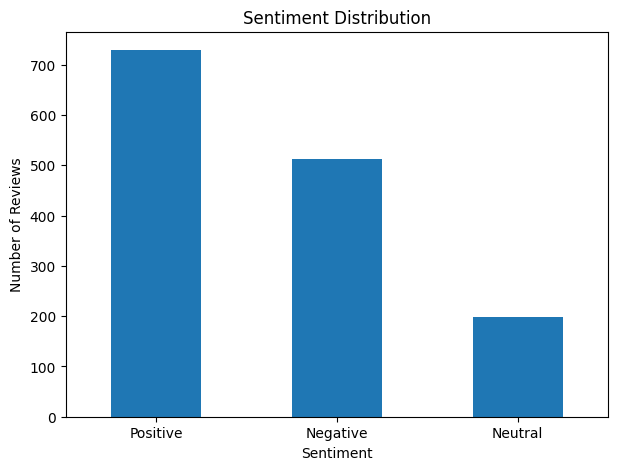

In [33]:
# Visualize Sentiment Distribution
df["sentiment"].value_counts().plot(kind="bar", figsize=(7, 5))

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

**The dataset contains more positive reviews than negative reviews, while neutral reviews are comparatively fewer.**

**This means the dataset is not perfectly balanced. The model may have more exposure to Positive examples during training.**

**The sentiment distribution shows that positive reviews dominate the dataset, followed by negative reviews, while neutral reviews are the least represented. Therefore, model evaluation should consider not only accuracy but also precision, recall, and F1-score, particularly for the minority Neutral class.**

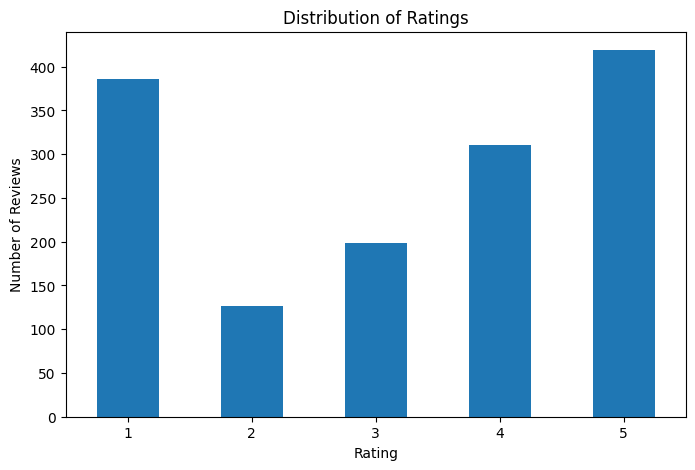

In [34]:
# Visualize distribution of Ratings
plt.figure(figsize=(8, 5))

df["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

**5-star reviews are the highest**

**1-star reviews are also quite high**

**4-star reviews are the next**
**significant group**

**3-star reviews are moderate**

**2-star reviews are the least common**

**The rating distribution is polarized** **toward the extreme** ratings, particularly 1-star and 5-star reviews. Lower ratings **indicate strong dissatisfaction, **whereas higher ratings indicate strong satisfaction.**

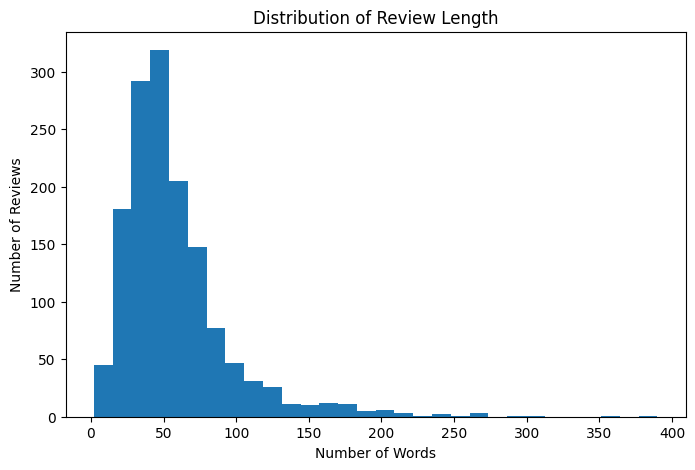

In [35]:
# Visualize Distribution of review length
df["review_length"] = df["clean_text"].str.split().str.len()

plt.figure(figsize=(8, 5))
plt.hist(df["review_length"], bins=30)
plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

**The review-length distribution is right-skewed, indicating that most reviews are relatively short, while a small number of reviews are considerably longer. This makes TF-IDF with a controlled vocabulary and n-grams suitable for representing the review text.**

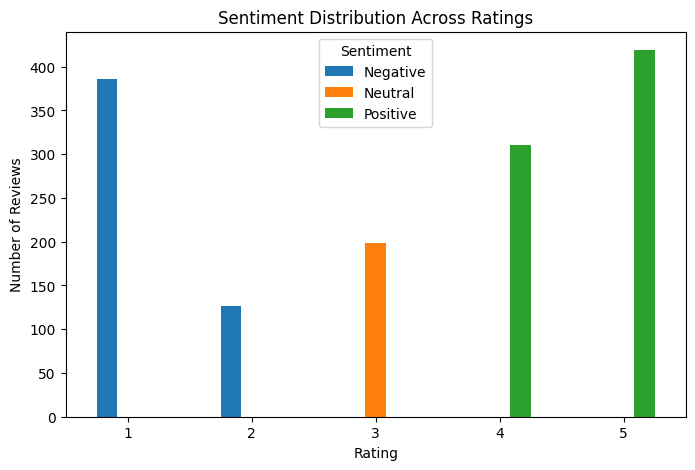

In [36]:
# Visualize Sentiment Distribution Across Ratings
sentiment_rating = pd.crosstab(
    df["rating"],
    df["sentiment"]
)

sentiment_rating.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sentiment Distribution Across Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.show()

**The visualization confirms the mapping between customer ratings and the derived sentiment labels. Ratings 1 and 2 correspond to Negative sentiment, rating 3 corresponds to Neutral sentiment, and ratings 4 and 5 correspond to Positive sentiment.**

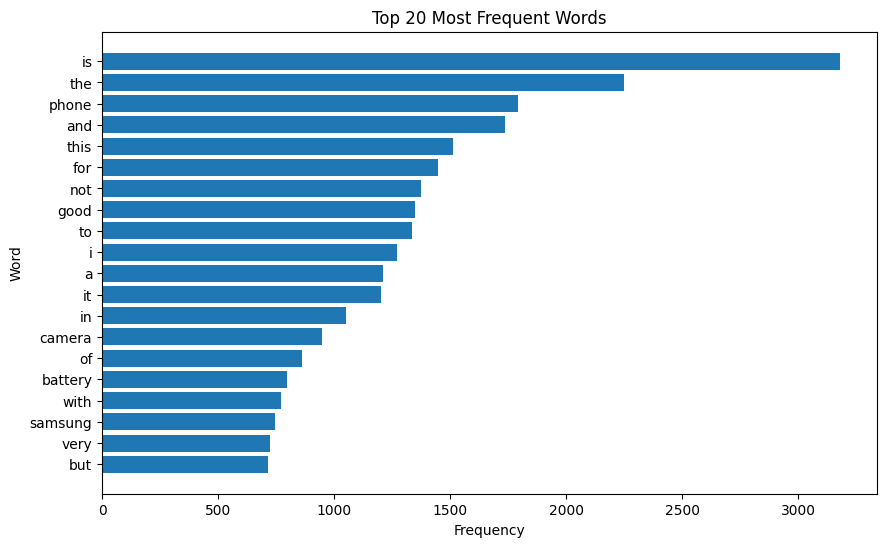

In [37]:
# Visualize Top 20 most frequent words
from collections import Counter

words = " ".join(df["clean_text"]).split()

word_counts = Counter(words)

top_words = word_counts.most_common(20)

words_df = pd.DataFrame(
    top_words,
    columns=["word", "count"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    words_df["word"][::-1],
    words_df["count"][::-1]
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

In [38]:
!pip install wordcloud

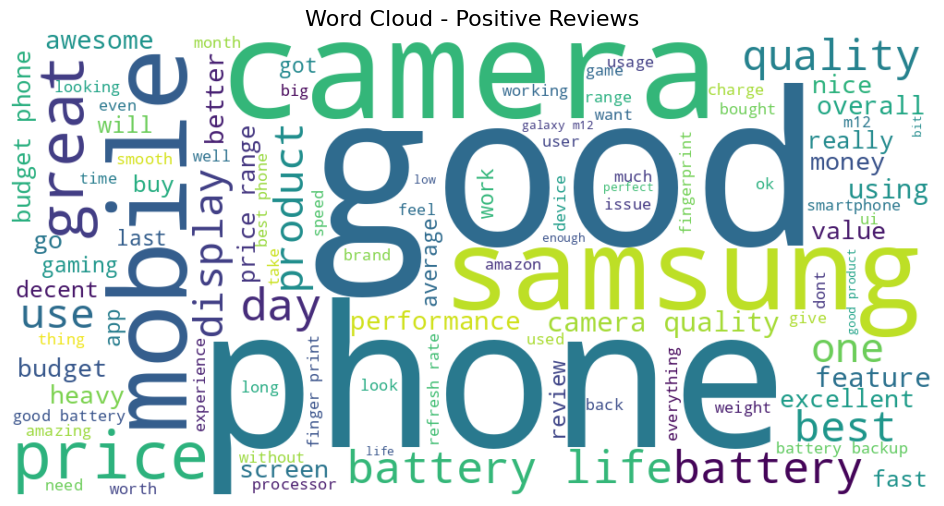

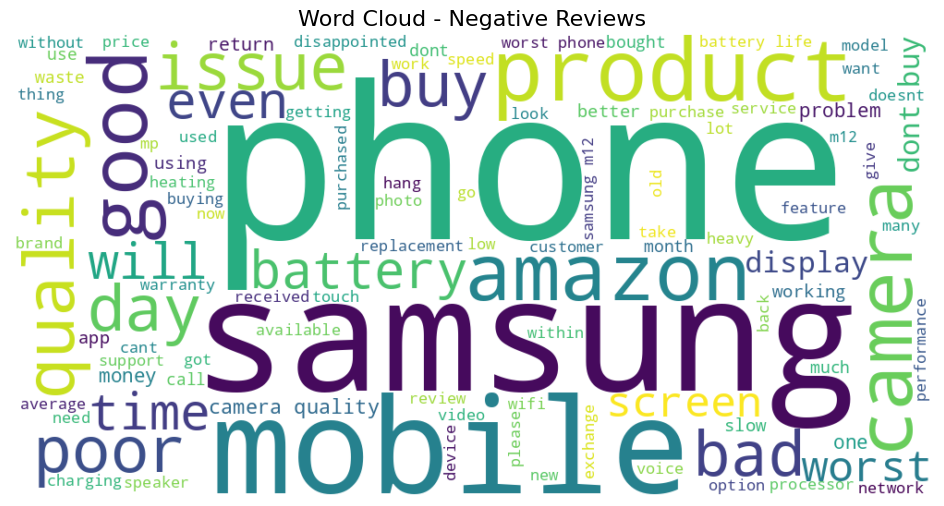

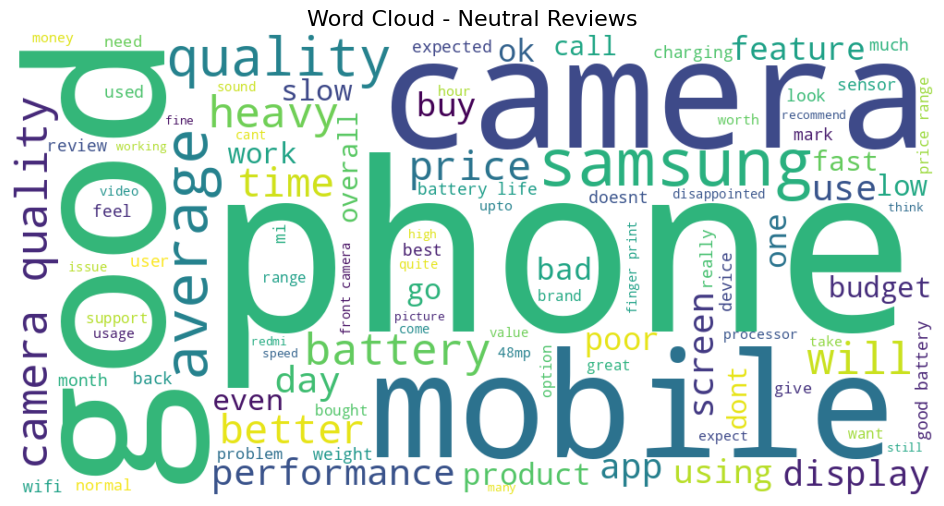

In [41]:
# World Cloud Visualization
from wordcloud import WordCloud
import matplotlib.pyplot as plt

sentiments = ["Positive", "Negative", "Neutral"]

for sentiment in sentiments:

    # Get text for each sentiment
    text = " ".join(
        df[df["sentiment"] == sentiment]["clean_text"].astype(str)
    )

    # Generate Word Cloud
    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100
    ).generate(text)

    # Create separate graph
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud - {sentiment} Reviews", fontsize=16)
    plt.show()

# **Feature Engineering & Data split**

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Separate text and target
X_text = df["clean_text"]
y = df["sentiment"]

# Train-test split
X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.20, random_state=42, stratify=y)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Fit only on training data
X_train = tfidf.fit_transform(X_train_text)

# Transform test data using the same vocabulary
X_test = tfidf.transform(X_test_text)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1152, 5000)
X_test: (288, 5000)
y_train: (1152,)
y_test: (288,)


# **EDA Conclusion**


The dataset contains customer reviews related to mobile phones, with sentiment labels derived from the ratings. The exploratory data analysis provided the following key insights:

- The dataset contains reviews with all three sentiment categories: Positive, Negative, and Neutral.
- Positive reviews form the largest proportion of the dataset, followed by Negative and Neutral reviews, indicating some class imbalance.
- The rating distribution shows that ratings 5 and 1 are relatively prominent, suggesting that customers have both highly positive and highly negative opinions about the products.
- Most reviews are relatively short, although a small number of reviews are significantly longer.
- Frequently occurring words are mainly related to important product features such as phone, camera, battery, screen, display, quality, price, and performance.
- The sentiment distribution and rating distribution indicate that customer opinions are somewhat polarized, with many reviews expressing strong positive or negative experiences.
- Since the dataset contains reviews in multiple languages and some code-mixed text, non-English reviews were translated into English before further NLP processing.
- TF-IDF was selected to convert the cleaned textual data into numerical features for machine learning.

Overall, the EDA shows that the dataset contains meaningful textual patterns that can be used for sentiment classification. Based on these observations, the next step is to train and compare different traditional machine learning models and evaluate their performance using appropriate classification metrics.